# Add library

In [10]:
from keras.layers import Conv2D, BatchNormalization, LeakyReLU, Dropout, Dense
from keras.layers import MaxPool2D, Input, GlobalAveragePooling2D,Flatten
from keras.models import load_model, Model
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np


# Read csv file

In [11]:
import pandas as pd
data = pd.read_csv('../input/digit-recognizer/train.csv')  


In [12]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
labels = data[data.columns[0]]
pixels = data.columns[1:]

In [14]:
allImages = np.array(data.loc[:,pixels])
               

In [15]:
print(allImages.shape)

(42000, 784)


In [16]:
allImages = np.reshape(allImages,(allImages.shape[0],28,28,1))

In [17]:
print(allImages.shape)
allImages = allImages/256

(42000, 28, 28, 1)


label:  0


(<matplotlib.image.AxesImage at 0x7fc0ddfe4c50>, None)

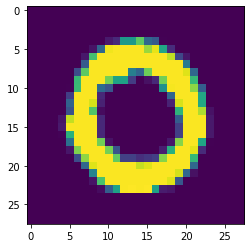

In [18]:

plt.imshow(allImages[1]),print('label: ',labels[1])

# convert labels to one-hot encoding

In [19]:
y=list(labels)
len_y = len(y)
len_y
y_onehot = np.zeros((len_y,10))
y_onehot.shape
for i in range(len_y):
    y_onehot[i,y[i]]=1

In [20]:
y[0:5]

[1, 0, 1, 4, 0]

In [21]:
y_onehot[0:5]

array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [22]:
x = allImages
y = y_onehot

In [23]:
x.shape

(42000, 28, 28, 1)

In [24]:
model = tf.keras.Sequential()

model.add(Conv2D(filters = 16, kernel_size = (3,3),padding = 'Same', input_shape = (28,28,1)))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.05))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters = 32, kernel_size = (3,3),padding = 'Same'))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.05))
model.add(MaxPool2D(pool_size=(2,2)))



model.add(Conv2D(filters = 64, kernel_size = (3,3), padding = 'Same'))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.05))



model.add(Conv2D(filters = 16, kernel_size = (3,3),padding = 'Same'))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.05))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

model.add(Flatten())
model.add(Dense(256))
model.add(Dropout(0.5))

model.add(LeakyReLU(alpha=0.05))

model.add(Dense(10, activation = "softmax"))

In [25]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 28, 28, 16)        160       
_________________________________________________________________
batch_normalization (BatchNo (None, 28, 28, 16)        64        
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 28, 28, 16)        0         
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 14, 14, 16)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 14, 14, 32)        4640      
_________________________________________________________________
batch_normalization_1 (Batch (None, 14, 14, 32)        128       
_________________________________________________________________
leaky_re_lu_1 (LeakyReLU)    (None, 14, 14, 32)        0

In [26]:

opt = tf.keras.optimizers.Adam(learning_rate=0.008)
model.compile(optimizer = opt , loss = "categorical_crossentropy", metrics=["accuracy"])

In [27]:
epoch = 10
batch_size = 128
history = model.fit(x, y, validation_split=0.1,batch_size = batch_size, epochs=epoch,shuffle=True)

Epoch 1/10
296/296 [==============================] - 27s 89ms/step - loss: 0.6421 - accuracy: 0.8022 - val_loss: 3.0795 - val_accuracy: 0.4052
Epoch 2/10
296/296 [==============================] - 26s 89ms/step - loss: 0.0797 - accuracy: 0.9762 - val_loss: 0.1201 - val_accuracy: 0.9643
Epoch 3/10
296/296 [==============================] - 26s 89ms/step - loss: 0.0618 - accuracy: 0.9814 - val_loss: 0.0535 - val_accuracy: 0.9840
Epoch 4/10
296/296 [==============================] - 26s 87ms/step - loss: 0.0447 - accuracy: 0.9866 - val_loss: 0.0729 - val_accuracy: 0.9764
Epoch 5/10
296/296 [==============================] - 26s 87ms/step - loss: 0.0371 - accuracy: 0.9889 - val_loss: 0.0367 - val_accuracy: 0.9876
Epoch 6/10
296/296 [==============================] - 25s 86ms/step - loss: 0.0322 - accuracy: 0.9907 - val_loss: 0.0406 - val_accuracy: 0.9871
Epoch 7/10
296/296 [==============================] - 26s 87ms/step - loss: 0.0287 - accuracy: 0.9912 - val_loss: 0.0405 - val_accuracy:

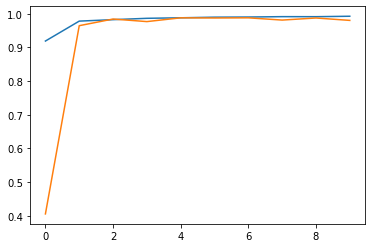

In [29]:


train_loss = history.history['accuracy']
val_loss   = history.history['val_accuracy']


xc = range(10)

plt.figure()
plt.plot(xc, train_loss)
plt.plot(xc, val_loss)

In [30]:
import pandas as pd
data_test = pd.read_csv('../input/digit-recognizer/test.csv')  


In [31]:
data_test

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:

pixels_test = data_test.columns[0:]

In [33]:
allImages_test = np.array(data_test.loc[:,pixels_test])
print(allImages_test.shape)

(28000, 784)


In [34]:
allImages_test = np.reshape(allImages_test,(allImages_test.shape[0],28,28,1))
print(allImages_test.shape)
allImages_test = allImages_test/256

(28000, 28, 28, 1)


(28, 28, 1)


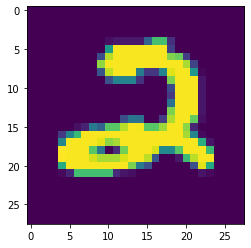

In [35]:
plt.imshow(allImages_test[0])
print(allImages_test[0].shape)

In [36]:
len(allImages_test), allImages_test.shape

(28000, (28000, 28, 28, 1))

In [37]:
#allImages_test
file1 = open("./myResult.txt","w") 


for i in range(len(allImages_test)):
        image_test = np.expand_dims(allImages_test[i],axis=0)
        pred = model.predict(image_test)[0]
        index = np.where(pred == np.max(pred))
        file1.write(str(i)+","+str(index[0][0]))
        file1.write("\n")

file1.close() 
  